In [ ]:
from math import sin, cos, pi, sqrt

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# All distances are in meters, pressure in pascals, force in newtons.
ATMOSPHERIC_PRESSURE = 101325  # Pa
GAMMA = 1.35                   # approximate specific heat ratio

# Cylinder
CYLINDER_BORE = 0.108          # m, cylinder inside diameter
CYLINDER_STROKE = 0.0884       # m, piston travel distance
CYLINDER_ROD = 0.156           # m, connecting rod length
CYLINDER_CLEARANCE_HEIGHT = 0.012  # m, gas height above piston at TDC

# Simulation
RPM = 1000 # Engine speed
SIM_DT = 0.0001 # Time step
SIM_TIME = 0.2 # Simulation time

In [ ]:
# Cylinder
piston_area = pi * (CYLINDER_BORE / 2) ** 2
clearance_volume = piston_area * CYLINDER_CLEARANCE_HEIGHT

# Crankshaft
crank_radius = CYLINDER_STROKE / 2

def calc_cylinder_volume(crank_angle):
    piston_height = (
        crank_radius * (1 - cos(crank_angle))
        + CYLINDER_ROD * (
            1 - sqrt(
                1 - (crank_radius / CYLINDER_ROD * sin(crank_angle)) ** 2
            )
        )
    )
    return clearance_volume + piston_area * piston_height

reference_angle = pi
reference_volume = calc_cylinder_volume(reference_angle)

def calc_cylinder_pressure(crank_angle):
    # Closed, adiabatic compression/expansion approximation.
    volume = calc_cylinder_volume(crank_angle)
    return ATMOSPHERIC_PRESSURE * (reference_volume / volume) ** GAMMA

def calc_piston_force(crank_angle):
    cylinder_gauge_pressure = calc_cylinder_pressure(crank_angle) - ATMOSPHERIC_PRESSURE
    return piston_area * cylinder_gauge_pressure

def calc_crank_torque_simple(crank_angle):
    # Approximation: connecting-rod angle is ignored.
    return calc_piston_force(crank_angle) * crank_radius * sin(crank_angle)

In [ ]:
N_steps = int(SIM_TIME / SIM_DT)

angular_velocity = RPM * 2 * pi / 60
crank_angle = 0

time_history = np.zeros(N_steps)
crank_angle_history = np.zeros(N_steps)
crank_torque_history = np.zeros(N_steps)

for step in range(N_steps):

    time = step * SIM_DT
    crank_angle = angular_velocity * time
    crank_torque = calc_crank_torque_simple(crank_angle)

    time_history[step] = step * SIM_DT
    crank_angle_history[step] = crank_angle
    crank_torque_history[step] = crank_torque

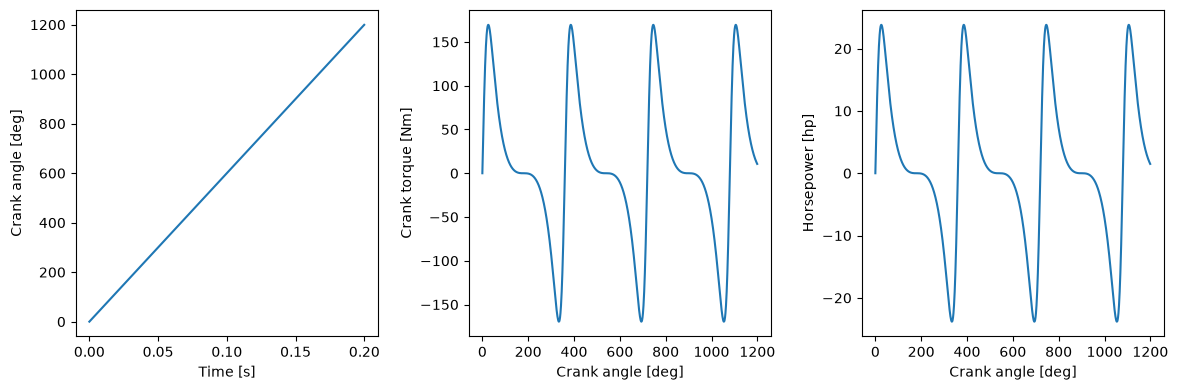

In [9]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
# Crank angle at fixed RPM
ax = axes[0]
ax.set_xlabel('Time [s]') ; ax.set_ylabel('Crank angle [deg]')
ax.plot(time_history, crank_angle_history*180/pi)

# Crank torque
ax = axes[1]
ax.set_xlabel('Crank angle [deg]') ; ax.set_ylabel('Crank torque [Nm]')
ax.plot(crank_angle_history*180/pi, crank_torque_history)

# Instantaneous power
ax = axes[2]
ax.set_xlabel('Crank angle [deg]') ; ax.set_ylabel('Horsepower [hp]')
ax.plot(crank_angle_history*180/pi, crank_torque_history * angular_velocity / 745.7)

plt.tight_layout()
plt.show()